In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, skew, mannwhitneyu
import statsmodels.stats.power as smp
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Load the data.
df = pd.read_excel('Time_for_Bac_Fix_Pos50_Start.xlsx')
df.head()

,Normal Equation,No Conj,No R_a with Conj,No R_a No Conj
0,1640,8389,11341,4639
1,6705,10295,4598,5957
2,4174,3898,4262,10392
3,5143,6651,4249,7612
4,6589,6044,6387,11958


### Descriptive Statistics

- Normal Equation: in this case means the unaltered model with both R_a and the conjugation equation.
- No Conj: is the model with R_a but without conjugation.
- No R_a with Conj: is the model without R_a, (bacteria do not slow down in antibiotic), and with conjugation.
- No R_a No Conj: is the model without R_a, and without conjugation.

In [3]:
df.describe()

,Normal Equation,No Conj,No R_a with Conj,No R_a No Conj
count,100.000000,100.000000,100.000000,100.00000
mean,6237.420000,6887.230000,7094.050000,7145.96000
std,3810.914721,4105.508002,3067.210559,3677.99852
min,1542.000000,1351.000000,2120.000000,1009.00000
25%,3865.000000,4148.750000,4582.500000,4890.25000
50%,5119.000000,5575.500000,6600.000000,6399.50000
75%,7276.500000,8511.500000,9096.250000,9099.75000
max,19492.000000,20570.000000,18508.000000,21687.00000


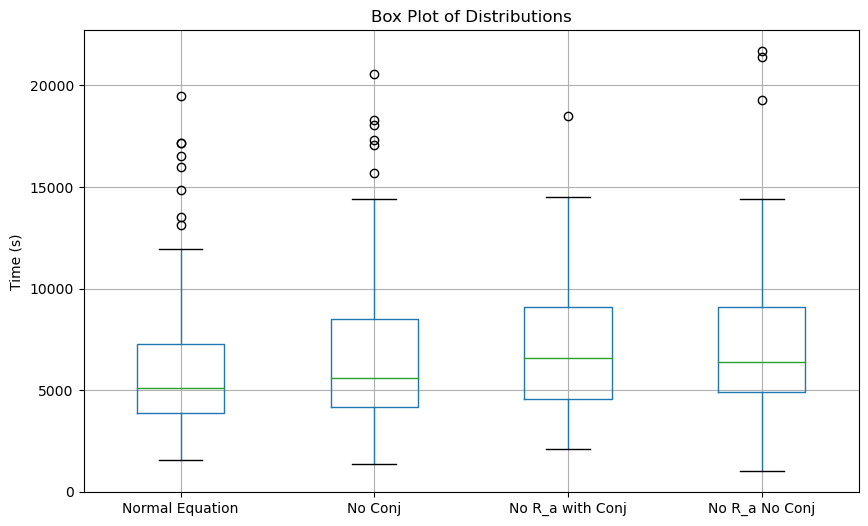

In [4]:
# Step 1: Visualize the Data
plt.figure(figsize=(10, 6))
df.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

### Data Cleaning

In [3]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Normal Equation'] = remove_outliers(df, 'Normal Equation')['Normal Equation']
df_cleaned['No Conj'] = remove_outliers(df, 'No Conj')['No Conj']
df_cleaned['No R_a with Conj'] = remove_outliers(df, 'No R_a with Conj')['No R_a with Conj']
df_cleaned['No R_a No Conj'] = remove_outliers(df, 'No R_a No Conj')['No R_a No Conj']
df_cleaned.describe()

,Normal Equation,No Conj,No R_a with Conj,No R_a No Conj
count,92.000000,94.000000,99.000000,97.000000
mean,5390.663043,6188.968085,6978.757576,6723.927835
std,2529.713293,3096.253263,2856.742979,2813.514003
min,1542.000000,1351.000000,2120.000000,1009.000000
25%,3418.000000,4031.750000,4567.000000,4870.000000
50%,5001.500000,5390.000000,6559.000000,6383.000000
75%,6807.500000,8003.500000,9070.000000,8160.000000
max,11935.000000,14386.000000,14518.000000,14410.000000


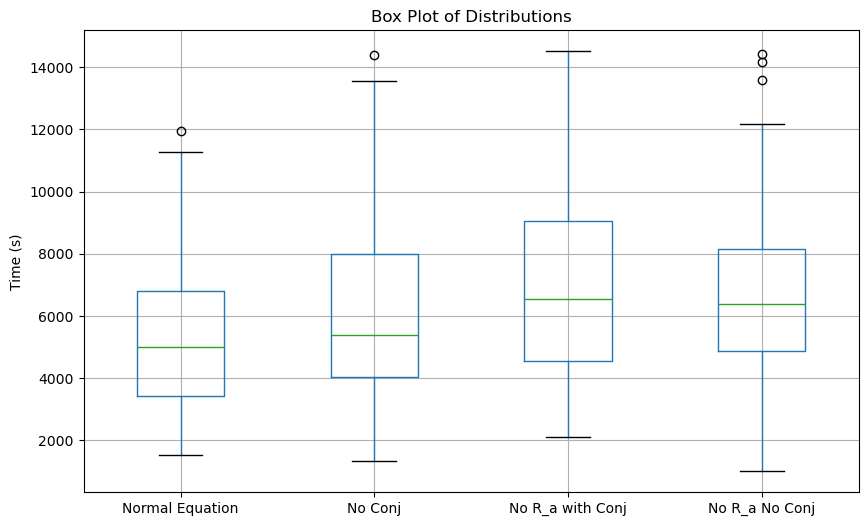

In [4]:
# Visualize the Data
plt.figure(figsize=(10, 6))
df_cleaned.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

Letter-value plots (boxenplots) start with the median (Q2, 50th percentile) as the centerline. Each successive level outward contains half of the remaining data. So the first two sections out from the centerline contain 50% of the data. After that, the next two sections contain 25% of the data. This continues until we are at the outlier level. Each level out is shaded lighter. There are 4 methods for calculating outliers (described in the paper and available in seaborn). The default is to end up with around 5-8 outliers in each tail.

Text(0, 0.5, 'Time (s)')

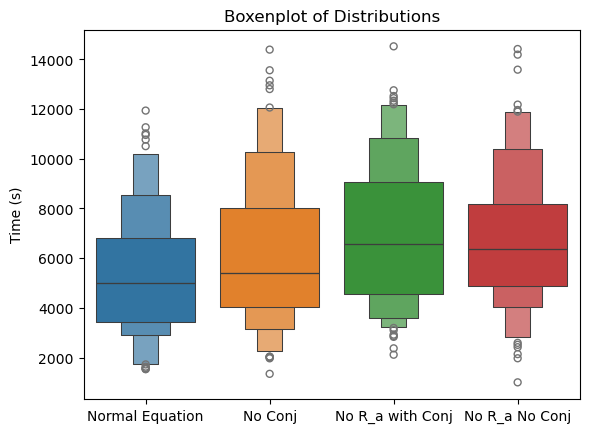

In [7]:
sns.boxenplot(data=df_cleaned)
plt.title('Boxenplot of Distributions')
plt.ylabel('Time (s)')

### Data Normalization and Histograms

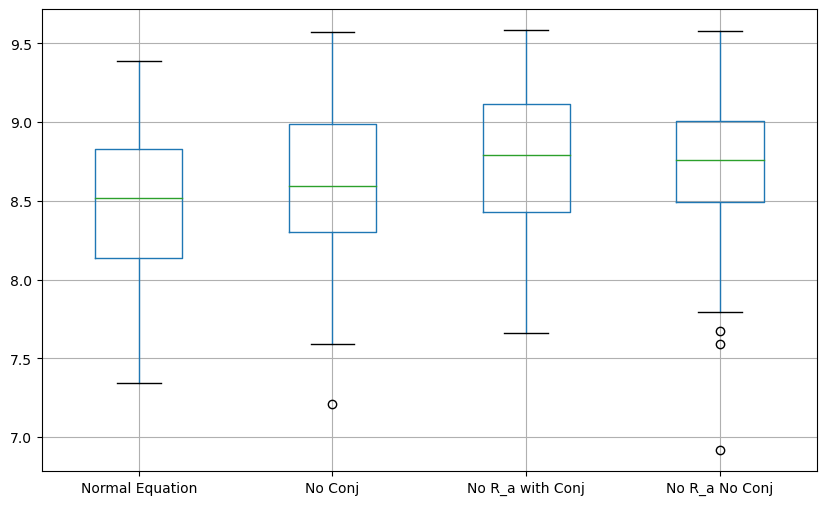

In [45]:
normalized_df_cleaned = df_cleaned.apply(lambda x: np.log(x))

# Visualize the Data
plt.figure(figsize=(10, 6))
normalized_df_cleaned.boxplot()
plt.show()

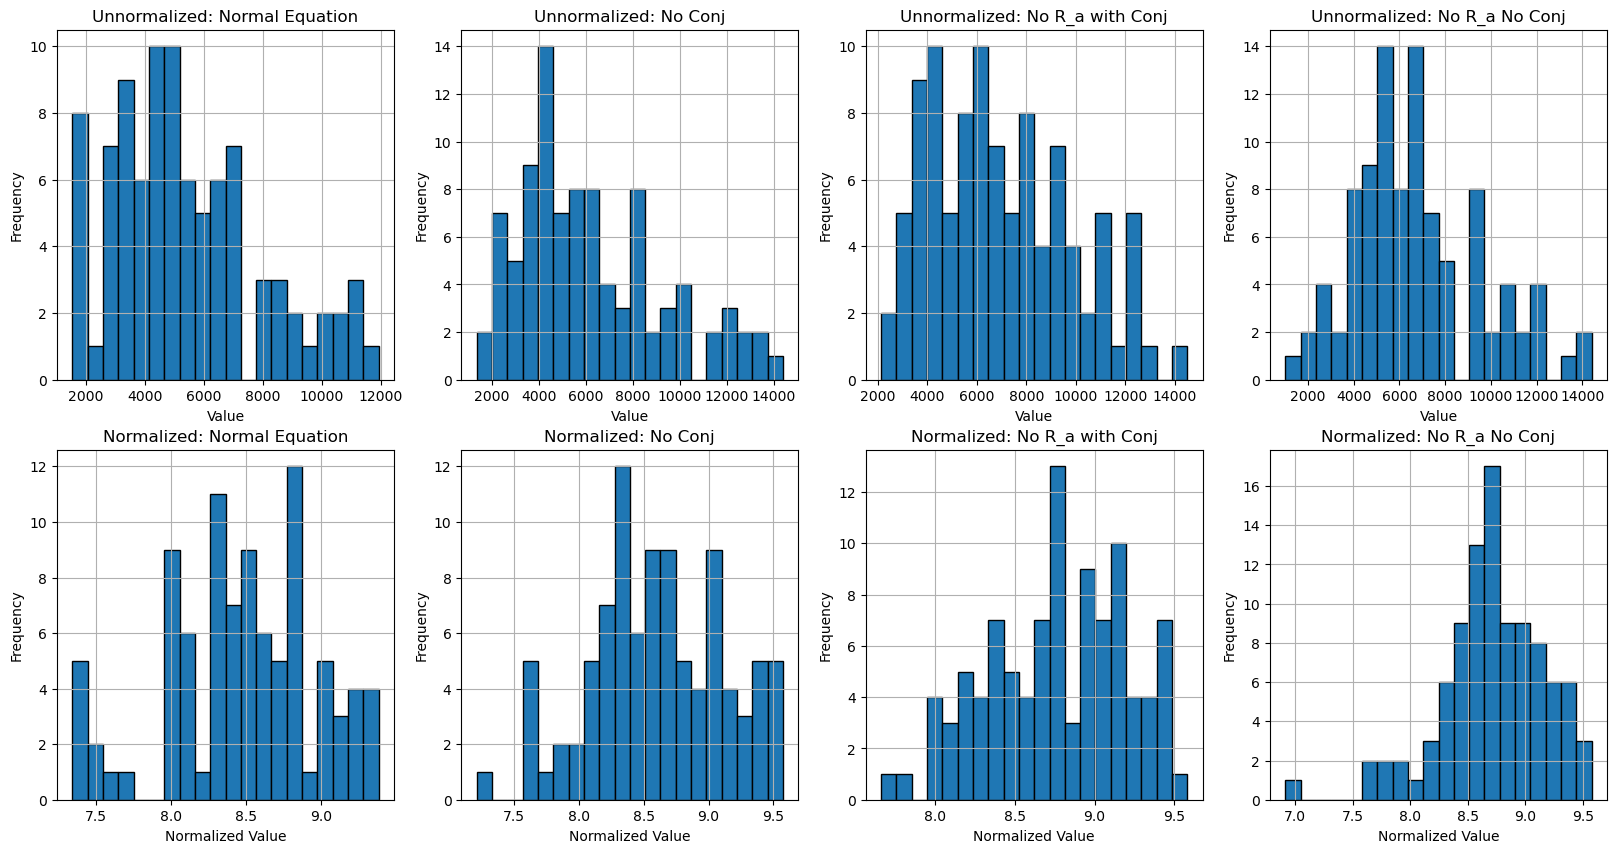

In [44]:
normalized_df_cleaned = df_cleaned.apply(lambda x: np.log(x))

# Number of columns to plot
num_columns = len(df_cleaned.columns)

# Create subplots
fig, axs = plt.subplots(2, num_columns, figsize=(5 * num_columns, 10))

# Ensure axs is 2-dimensional, even if there is only one column
if num_columns == 1:
    axs = np.array([[axs[0]], [axs[1]]])

# Plot histograms for each column in unnormalized data
for i, column in enumerate(df_cleaned.columns):
    df_cleaned[column].hist(ax=axs[0, i], bins=20, edgecolor='k')
    axs[0, i].set_title(f'Unnormalized: {column}')
    axs[0, i].set_xlabel('Value')
    axs[0, i].set_ylabel('Frequency')

# Plot histograms for each column in normalized data
for i, column in enumerate(normalized_df_cleaned.columns):
    normalized_df_cleaned[column].hist(ax=axs[1, i], bins=20, edgecolor='k')
    axs[1, i].set_title(f'Normalized: {column}')
    axs[1, i].set_xlabel('Normalized Value')
    axs[1, i].set_ylabel('Frequency')

### Power Analysis

In [14]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Normal Equation'] = remove_outliers(df, 'Normal Equation')['Normal Equation']
df_cleaned['No Conj'] = remove_outliers(df, 'No Conj')['No Conj']
df_cleaned['No R_a with Conj'] = remove_outliers(df, 'No R_a with Conj')['No R_a with Conj']
df_cleaned['No R_a No Conj'] = remove_outliers(df, 'No R_a No Conj')['No R_a No Conj']
df_cleaned.describe()

,Normal Equation,No Conj,No R_a with Conj,No R_a No Conj
count,92.000000,94.000000,99.000000,97.000000
mean,5390.663043,6188.968085,6978.757576,6723.927835
std,2529.713293,3096.253263,2856.742979,2813.514003
min,1542.000000,1351.000000,2120.000000,1009.000000
25%,3418.000000,4031.750000,4567.000000,4870.000000
50%,5001.500000,5390.000000,6559.000000,6383.000000
75%,6807.500000,8003.500000,9070.000000,8160.000000
max,11935.000000,14386.000000,14518.000000,14410.000000


**Comparing Normal Equation data to others.**

Comparing the Normal Equation data, (unaltered model), with 'No R_a No Conj', (model where bacteria do not slow down in antibiotic, and have no conjugation).

In [5]:
# Calculate Skewness of a data set.
skew_normal = skew(df_cleaned['Normal Equation'].dropna())
skew_no_ra_no_conj = skew(df_cleaned['No R_a No Conj'].dropna())

# Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df_cleaned['Normal Equation'].dropna(), df_cleaned['No R_a No Conj'].dropna())

skew_normal, skew_no_ra_no_conj, u_stat, p_value_u

(0.6836515476736373, 0.6502666557821867, 3167.0, 0.0005735721066443286)

Skewness:
- Both distributions are positively skewed, as one can tell by their score.
- Normal Equation: 0.684
- No R_a No Conjugation: 0.650
- The smaller score for Normal Equation means the distribution is less skewed to the right, and more distributed around a lower time.

Median:
- Normal Equation: 5001.5
- No R_a No Conjugation: 6383.0

Mann-Whitney U Test:
- P-value: The p-value of 0.0006 is less than the common significance level of 0.05.  We can conclude that the null hypothesis is rejected and there is significant differences between the two distributions.  
- Even given the small sample size there is significant difference after removing the outliers.

Conclusion:
    There is significant differences between the two distributions, and the time for fixing in the 'Normal Equation' more likely to be lower as the median is lower than 'No R_a No Conj'.

In [6]:
# Calculate Skewness of a data set.
skew_normal = skew(df_cleaned['Normal Equation'].dropna())
skew_no_ra_w_conj = skew(df_cleaned['No R_a with Conj'].dropna())

# Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df_cleaned['Normal Equation'].dropna(), df_cleaned['No R_a with Conj'].dropna())

skew_normal, skew_no_ra_w_conj, u_stat, p_value_u

(0.6836515476736373, 0.44725789802948, 3091.0, 0.00012755219885552408)

Skewness:
- Both distributions are positively skewed, as one can tell by their score.
- Normal Equation: 0.684
- No R_a with Conj: 0.447
- The smaller score for Normal Equation means the distribution is more skewed and has a longer right tail.

Median:
- Normal Equation: 5001.5
- No R_a with Conj: 6559.0

Mann-Whitney U Test:
- P-value: The p-value of 0.0001 is less than the common significance level of 0.05.  We can conclude that the null hypothesis is rejected and there is significant differences between the two distributions.  
- Even given the small sample size there is significant difference after removing the outliers.

Conclusion:
    There is significant differences between the two distributions, and the time for fixing in the 'Normal Equation' more likely to be lower as the median is lower than 'No R_a No Conj'.  While Normal Equation is more skewed, the distribution is more concentrated along a lower time than No R_a with Conj.

**Conclusion:**

    Even with the skew, the 75% percentile for the Normal Distribution is still lower than 'No R_a No Conj' and 'No R_a No Conj', (6807.5 vs 9070.0 and 8160.0).

    The median of the Normal Equation is lower than the other distributions.

    The analysis supports the hypothesis that R_a​ is the dominant factor, and Conj is relatively negligible in its impact on the outcome variable.  The significant p-values and medians for comparisons involving "Normal Equaiton" vs "No R_a with Conj" or "No R_a No Conj" highlight the dominant impact of the R_a variable. While the negligible p-values between "Normal Equation" vs "No Conj" and "No R_a with Conj" vs "No R_a No Conj" support that the conjugation equation provides a negligible advantage for fixation. However, if the conjugation equation is combined with R_a, it can help give the bacteria a statistically significant advantage for fixing into a population, as can be seen with "Normal Equation" fixation time having a greater statistical difference and the lowest median.  This suggesting a synergistic relationship that could be explored further for optimizing bacterial fixation strategies with a more advanced conjugation and plasmid model.
    
    A mutation occuring near or within the antibiotic alongside how quickly that mutant migrates towards the area to fix in a low wildtype population is the greatest variable for time to fixation.  This stochastic factor is the cause of the high variability.

**No Conj vs. No R_a with Conj**

In [16]:
# Mann-Whitney U Test for No Conj vs No R_a with Conj
u_stat_no_conj_no_ra_conj, p_value_no_conj_no_ra_conj = mannwhitneyu(df_cleaned['No Conj'].dropna(), df_cleaned['No R_a with Conj'].dropna())
u_stat_no_conj_no_ra_conj, p_value_no_conj_no_ra_conj

(3811.5, 0.030141547506305013)

- The significant p-value from the Mann-Whitney U test may be reflecting the underlying variability in R_a​ rather than a true effect of Conj.  This is also supported because comparing models with and without conjugation gives a negligible result.
- The analysis supports the hypothesis that R_a​ is the dominant factor, and Conj is negligible in its impact on the outcome variable.  This may be due to the higher variability of R_a.  See regression analysis.

**The Remaining Comparisons are not Statistically Significant**

In [8]:
# Normal Equation and No Conj are not statistically significant.
skew_normal = skew(df['Normal Equation'])
skew_no_conj = skew(df['No Conj'].dropna())

# Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df_cleaned['Normal Equation'].dropna(), df_cleaned['No Conj'].dropna())

skew_normal, skew_no_conj, u_stat, p_value_u

(1.4239061887240152, 1.259974694380183, 3757.5, 0.12311856362356016)

In [15]:
# Mann-Whitney U Test for No Conj vs No R_a No Conj
u_stat_no_conj_no_ra_no_conj, p_value_no_conj_no_ra_no_conj = mannwhitneyu(df_cleaned['No Conj'].dropna(), df_cleaned['No R_a No Conj'].dropna())
u_stat_no_conj_no_ra_no_conj, p_value_no_conj_no_ra_no_conj

(3862.0, 0.06822415958716153)

In [12]:
# Mann-Whitney U Test for No R_a with Conj vs No R_a No Conj
u_stat_no_ra_conj_no_ra_no_conj, p_value_no_ra_conj_no_ra_no_conj = mannwhitneyu(df_cleaned['No R_a with Conj'].dropna(), df_cleaned['No R_a No Conj'].dropna())
u_stat_no_ra_conj_no_ra_no_conj, p_value_no_ra_conj_no_ra_no_conj

(5032.5, 0.5615568288860984)

### Sample Sizes

In [14]:
def calculate_cohens_d(column_1, column_2):
    n1 = column_1.dropna().shape[0]
    mean_normal =column_1.dropna().mean()
    std_normal = column_1.std()
    n2 = column_2.dropna().shape[0]
    mean_no_conj = column_2.dropna().mean()
    std_no_conj = column_2.std()
    # Calculate pooled standard deviation
    s_p = np.sqrt(((n1 - 1) * std_normal**2 + (n2 - 1) * std_no_conj**2) / (n1 + n2 - 2))
    # Calculate Cohen's d, (the effect size in power analysis to find required sample size using this sample data).
    return abs(mean_normal - mean_no_conj)/s_p

In [15]:
# Calculate effect size between 'Normal Equatin' and 'No Conj'.
normal = df_cleaned['Normal Equation']
no_conj = df_cleaned['No Conj']
effect_size = calculate_cohens_d(normal, no_conj)

Power Analysis Inputs:
- Effect size (Cohen's d): Use the effect size estimated from the pilot study.
- Significance level (α): Typically set at 0.05.
- Power (1 - β): Commonly set at 0.80 or 0.90.
- Two-tailed test: If you are interested in differences in both directions.

In [16]:
# Perform power analysis
alpha = 0.05
power = 0.80

analysis = smp.NormalIndPower()
required_sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

effect_size, required_sample_size

(0.28205948307804735, 197.3127707585485)

In [ ]:
# Calculate effect size between 'No Conj' and 
no_conj = df_cleaned['No Conj']
normal = df_cleaned['Normal Equation']
effect_size = calculate_cohens_d(normal, no_conj)